# Machine Learning Project
# Cropping Cards for training use
# Kylle Waldie

### Imports

In [7]:
import cv2
import numpy as np
import os
import shutil

### Paths

In [8]:
GOOD_DIR    = r"C:\Users\wldky\OneDrive - Montana Tech\Spring-2026\CSCI 447\ML Project\dataset\sorted\good"
CROPPED_DIR = r"C:\Users\wldky\OneDrive - Montana Tech\Spring-2026\CSCI 447\ML Project\dataset\cropped"

### Settings

In [42]:
VALID_GRADES = {str(i) for i in range(1, 11)}

# How much of the bottom of the slab to cut off to remove the PSA grade label.
# PSA labels take up roughly the bottom 20% of the slab image.
LABEL_TRIM_RATIO = 0.20

# After finding the card region, add a small padding trim to remove
# any remaining slab border (as a fraction of the cropped region size).
INNER_TRIM_RATIO = 0.21

### Crop

In [43]:
def crop_card(img):
    h, w = img.shape[:2]

    # Trim the top label area 
    label_cutoff = int(h * LABEL_TRIM_RATIO)
    img_no_label = img[label_cutoff:, :]
    nh, nw = img_no_label.shape[:2]

    # Try to find card rectangle with edge detection
    gray    = cv2.cvtColor(img_no_label, cv2.COLOR_BGR2GRAY)
    blurred = cv2.GaussianBlur(gray, (5, 5), 0)

    # Try multiple Canny thresholds — dark cards need lower thresholds
    cropped = None
    for low, high in [(20, 80), (10, 50), (5, 30)]:
        edges  = cv2.Canny(blurred, low, high)
        kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (5, 5))
        edges  = cv2.dilate(edges, kernel, iterations=2)

        contours, _ = cv2.findContours(edges, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

        image_area   = nh * nw
        best_contour = None
        best_area    = 0

        for cnt in contours:
            area = cv2.contourArea(cnt)
            if area < image_area * 0.10 or area > image_area * 0.98:
                continue
            peri   = cv2.arcLength(cnt, True)
            approx = cv2.approxPolyDP(cnt, 0.02 * peri, True)
            if not (4 <= len(approx) <= 8):
                continue
            x, y, cw, ch = cv2.boundingRect(cnt)
            aspect = min(cw, ch) / max(cw, ch)
            if not (0.50 <= aspect <= 0.95):
                continue
            if area > best_area:
                best_area    = area
                best_contour = cnt

        if best_contour is not None:
            x, y, cw, ch = cv2.boundingRect(best_contour)
            trim_x = int(cw * INNER_TRIM_RATIO)
            trim_y = int(ch * INNER_TRIM_RATIO)
            x1 = max(0, x + trim_x)
            y1 = max(0, y + trim_y)
            x2 = min(nw, x + cw - trim_x)
            y2 = min(nh, y + ch - trim_y)
            cropped = img_no_label[y1:y2, x1:x2]
            if cropped.shape[0] >= 50 and cropped.shape[1] >= 50:
                break  # Found a good crop, stop trying

    # Fallback — use fixed proportions based on slab layout 
    # If edge detection completely fails, estimate the card position based on typical PSA slab proportions.
    if cropped is None or cropped.shape[0] < 50 or cropped.shape[1] < 50:
        pad_x  = int(nw * 0.09)   # slab has ~6% plastic border on left/right
        pad_y  = int(nh * 0.07)   # small border on top/bottom after label trim
        x1, y1 = pad_x, pad_y
        x2, y2 = nw - pad_x, nh - pad_y
        cropped = img_no_label[y1:y2, x1:x2]

    return cropped

### Preview Crop

In [44]:
def preview_crop(image_path):
    """
    Show a side-by-side preview of original vs cropped for a single image.
    Useful for testing before running the full batch.
    """
    import matplotlib.pyplot as plt

    img    = cv2.imread(image_path)
    if img is None:
        print(f"Could not read: {image_path}")
        return

    cropped = crop_card(img)

    fig, axes = plt.subplots(1, 2, figsize=(10, 6))
    axes[0].imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    axes[0].set_title("Original")
    axes[0].axis('off')

    if cropped is not None:
        axes[1].imshow(cv2.cvtColor(cropped, cv2.COLOR_BGR2RGB))
        axes[1].set_title("Cropped Card")
    else:
        axes[1].set_title("Crop Failed")
    axes[1].axis('off')

    plt.tight_layout()
    plt.show()

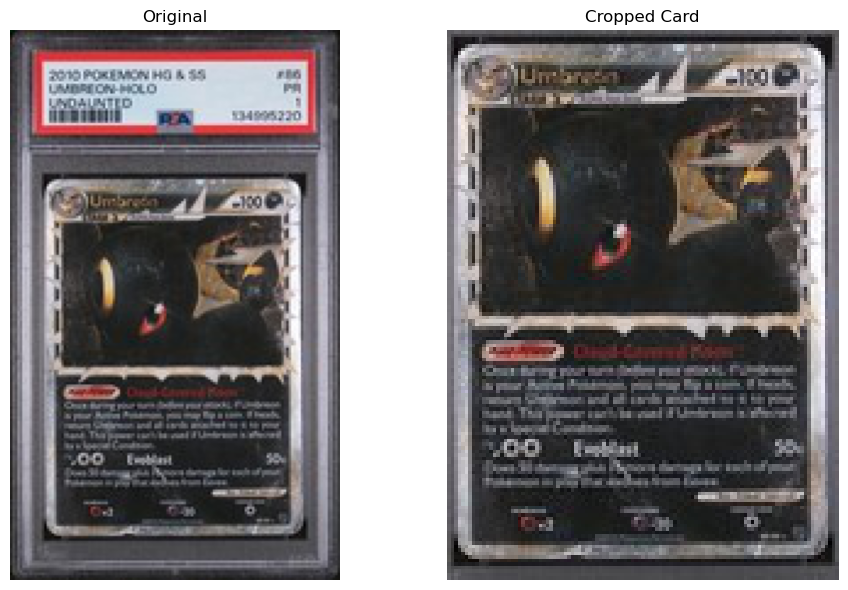

In [45]:
preview_crop(r"C:\Users\wldky\OneDrive - Montana Tech\Spring-2026\CSCI 447\ML Project\dataset\sorted\good\PSA_1\psa_1_1.jpg")

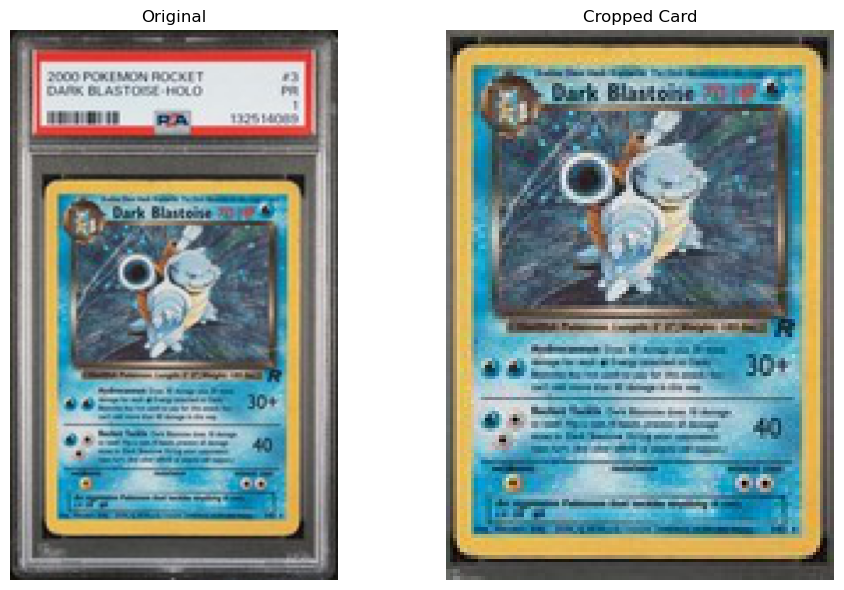

In [46]:
preview_crop(r"C:\Users\wldky\OneDrive - Montana Tech\Spring-2026\CSCI 447\ML Project\dataset\sorted\good\PSA_1\psa_1_12.jpg")

### Crop all

In [47]:
def crop_all():
    psa_folders = sorted([
        f for f in os.listdir(GOOD_DIR)
        if os.path.isdir(os.path.join(GOOD_DIR, f)) and f.lower().startswith('psa_')
    ])

    if not psa_folders:
        print(f"No PSA_* folders found in:\n  {GOOD_DIR}")
        return

    total_success = 0
    total_failed  = 0

    for psa_folder in psa_folders:
        grade_str = psa_folder.split('_')[1]
        if grade_str not in VALID_GRADES:
            print(f"Skipping invalid folder: {psa_folder}")
            continue

        src_folder = os.path.join(GOOD_DIR, psa_folder)
        dst_folder = os.path.join(CROPPED_DIR, psa_folder)
        os.makedirs(dst_folder, exist_ok=True)

        jpgs = [f for f in os.listdir(src_folder) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
        print(f"Processing {psa_folder} ({len(jpgs)} images)...")

        grade_success = 0
        grade_failed  = 0

        for filename in jpgs:
            src_path = os.path.join(src_folder, filename)
            dst_path = os.path.join(dst_folder, filename)

            # Skip if already cropped
            if os.path.exists(dst_path):
                grade_success += 1
                continue

            img     = cv2.imread(src_path)
            if img is None:
                grade_failed += 1
                continue

            cropped = crop_card(img)

            if cropped is not None:
                cv2.imwrite(dst_path, cropped)
                grade_success += 1
            else:
                # If cropping fails, copy the original so no images are lost
                shutil.copy2(src_path, dst_path)
                grade_failed += 1

        print(f"Cropped:       {grade_success}")
        if grade_failed > 0:
            print(f"Crop failed (original copied): {grade_failed}")
        print()

        total_success += grade_success
        total_failed  += grade_failed

    print(f"{'='*45}")
    print(f"All done!")
    print(f"Successfully cropped: {total_success}")
    if total_failed > 0:
        print(f" Failed (originals kept): {total_failed}")
    print(f"Cropped images saved to: {CROPPED_DIR}")
    print(f"{'='*45}")
    print(f"\nNext step: update GOOD_DIR in preprocess.py to point to:")
    print(f"  {CROPPED_DIR}")

### Running Func

In [48]:
crop_all()

Skipping invalid folder: PSA_08
Processing PSA_1 (48 images)...
Cropped:       48

Processing PSA_10 (312 images)...
Cropped:       312

Skipping invalid folder: PSA_13
Skipping invalid folder: PSA_15
Skipping invalid folder: PSA_19
Processing PSA_2 (28 images)...
Cropped:       28

Skipping invalid folder: PSA_20
Skipping invalid folder: PSA_23
Processing PSA_3 (374 images)...
Cropped:       374

Processing PSA_4 (410 images)...
Cropped:       410

Skipping invalid folder: PSA_40
Processing PSA_5 (872 images)...
Cropped:       872

Processing PSA_6 (484 images)...
Cropped:       484

Processing PSA_7 (1758 images)...
Cropped:       1758

Skipping invalid folder: PSA_70
Processing PSA_8 (1894 images)...
Cropped:       1894

Processing PSA_9 (1452 images)...
Cropped:       1452

All done!
Successfully cropped: 7632
Cropped images saved to: C:\Users\wldky\OneDrive - Montana Tech\Spring-2026\CSCI 447\ML Project\dataset\cropped

Next step: update GOOD_DIR in preprocess.py to point to:
  C: